# NG-DRI-EAF CCS steel NPV simulation

Run the Monte Carlo simulation for the NG-DRI-EAF CCS steel retrofit and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "ng_dri_eaf_ccs"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction
0,0,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,856.126578,44.3,313.430974,natural_gas,...,312.0,2.637871,1.06,0.666186,200.0,11.8,1.430974,0.0,-0.283019,0.64
1,1,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,857.615601,44.3,313.390851,natural_gas,...,312.0,2.537490,1.06,0.713460,200.0,11.8,1.390851,0.0,-0.283019,0.64
2,2,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,853.745983,44.3,313.344049,natural_gas,...,312.0,2.676089,1.06,0.716480,200.0,11.8,1.344049,0.0,-0.283019,0.64
3,3,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,854.262848,44.3,313.451507,natural_gas,...,312.0,2.682886,1.06,0.647644,200.0,11.8,1.451507,0.0,-0.283019,0.64
4,4,ng_dri_eaf_ccs,retrofit,sampled,1000000.0,20.0,859.448704,44.3,313.414998,natural_gas,...,312.0,2.595309,1.06,0.826310,200.0,11.8,1.414998,0.0,-0.283019,0.64


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-3773.728857,834.362620,-384.362620
std,617.891512,62.933615,62.933615
min,-5991.286403,625.584213,-610.225754
5%,-4772.724791,727.691412,-486.112562
50%,-3791.091161,836.131009,-386.131009
95%,-2726.415219,936.112562,-277.691412
max,-1723.911690,1060.225754,-175.584213


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


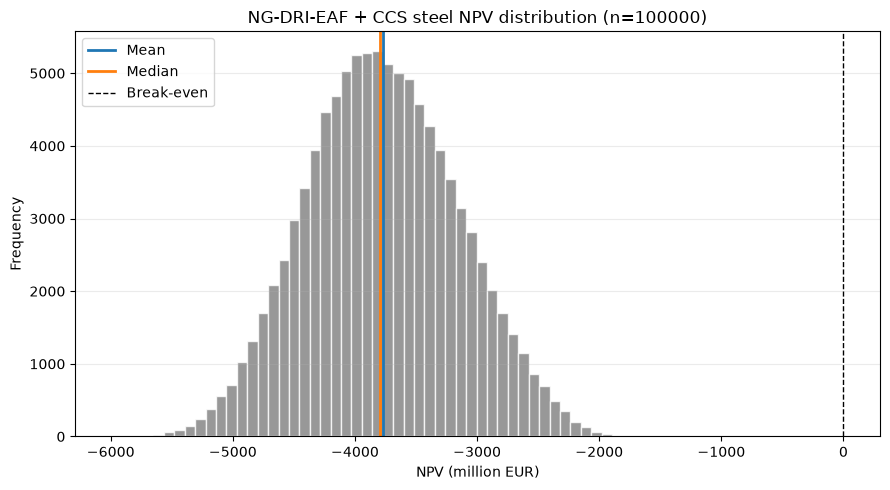

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"NG-DRI-EAF + CCS steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


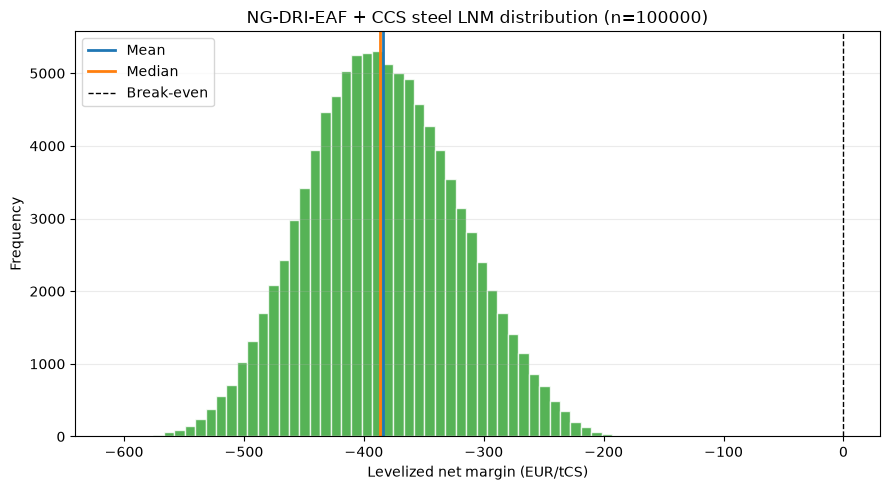

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"NG-DRI-EAF + CCS steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


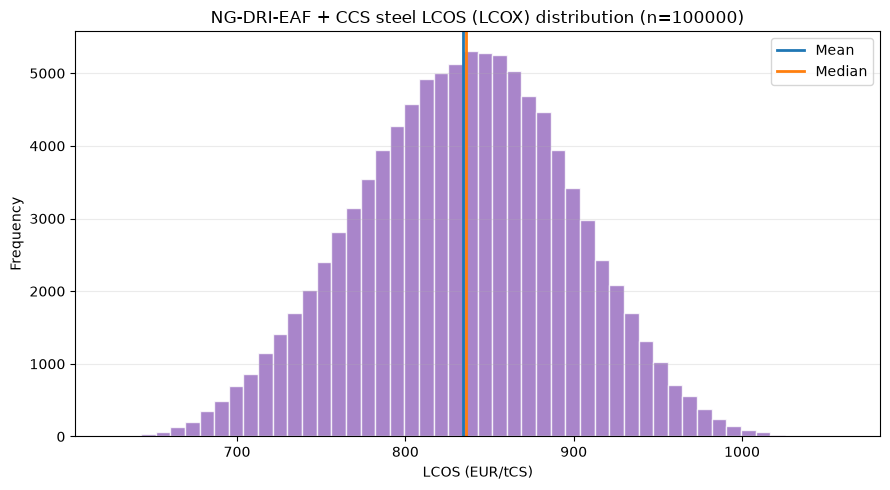

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"NG-DRI-EAF + CCS steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_transport_and_storage_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur                       450.000000
annual_fixed_opex_eur                     44.300000
annual_variable_opex_eur                 313.400226
annual_fuel_cost_eur                     102.511756
annual_electricity_cost_eur              249.784406
annual_transport_and_storage_cost_eur     16.581322
annual_emissions_cost_eur                 20.531008
annual_net_cash_flow_eur                -297.108717
Name: Mean annual value, million EUR, dtype: float64

In [8]:
retrofit_columns = [
    "capex_change_eur_per_tcs",
    "fixed_opex_change_eur_per_tcs",
    "variable_opex_change_eur_per_tcs",
    "fuel_consumption_reduction_fraction",
    "electricity_consumption_reduction_fraction",
    "emissions_reduction_fraction",
    "bau_capex_eur_per_tcs",
    "bau_fixed_opex_eur_per_tcs",
    "bau_variable_opex_eur_per_tcs",
    "bau_fuel_consumption_mwh_th_per_tcs",
    "bau_electricity_consumption_mwh_per_tcs",
    "bau_emissions_tco2_per_tcs",
    "transport_and_storage_share_of_capture_cost",
    "capture_cost_excluding_transport_and_storage_eur_per_tcs",
    "transport_and_storage_cost_eur_per_tcs",
]

available_retrofit_columns = [
    column for column in retrofit_columns if column in results
]
retrofit_summary = results[available_retrofit_columns].describe(
    percentiles=[0.05, 0.5, 0.95]
)
retrofit_summary


,capex_change_eur_per_tcs,fixed_opex_change_eur_per_tcs,variable_opex_change_eur_per_tcs,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction,bau_capex_eur_per_tcs,bau_fixed_opex_eur_per_tcs,bau_variable_opex_eur_per_tcs,bau_fuel_consumption_mwh_th_per_tcs,bau_electricity_consumption_mwh_per_tcs,bau_emissions_tco2_per_tcs,transport_and_storage_share_of_capture_cost,capture_cost_excluding_transport_and_storage_eur_per_tcs,transport_and_storage_cost_eur_per_tcs
count,100000.0,1.000000e+05,100000.000000,100000.0,1.000000e+05,1.000000e+05,100000.000000,100000.0,100000.0,100000.000000,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.000000
mean,200.0,1.180000e+01,1.400226,0.0,-2.830189e-01,6.400000e-01,656.671677,32.5,312.0,2.613329,1.060000e+00,0.712882,1.870000e-01,88.670169,16.581322
std,0.0,1.776366e-15,0.070453,0.0,1.110229e-16,1.110229e-16,2.349970,0.0,0.0,0.061334,2.220457e-16,0.101428,2.775571e-17,10.786481,2.017072
min,200.0,1.180000e+01,1.201004,0.0,-2.830189e-01,6.400000e-01,650.034376,32.5,312.0,2.440692,1.060000e+00,0.550687,1.870000e-01,56.451261,10.556386
5%,200.0,1.180000e+01,1.267623,0.0,-2.830189e-01,6.400000e-01,652.262761,32.5,312.0,2.498132,1.060000e+00,0.579853,1.870000e-01,69.668326,13.027977
50%,200.0,1.180000e+01,1.412051,0.0,-2.830189e-01,6.400000e-01,657.066376,32.5,312.0,2.623653,1.060000e+00,0.695873,1.870000e-01,89.456511,16.728368
95%,200.0,1.180000e+01,1.492334,0.0,-2.830189e-01,6.400000e-01,659.744682,32.5,312.0,2.693472,1.060000e+00,0.903904,1.870000e-01,104.945968,19.624896
max,200.0,1.180000e+01,1.500000,0.0,-2.830189e-01,6.400000e-01,659.999911,32.5,312.0,2.700000,1.060000e+00,0.998583,1.870000e-01,110.174757,20.602679
